# Preprocess Check

Quick notebook to load one or two raw images, run the preprocessing pipeline, and compare raw vs preprocessed outputs.

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / "src"))

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
import torch
import numpy as np
from pathlib import Path
from data.transforms import preprocess_image

plt.rcParams['figure.max_open_warning'] = 20

In [5]:
# 1) locate sample images (png / jpg)
from pathlib import Path

# assume this notebook is in MRI-Project/notebooks/
project_root = Path().resolve().parent
print("Project root:", project_root)

raw_dir = project_root / "data" / "raw"
print("Raw dir:", raw_dir)

files = []
if raw_dir.exists():
    files = list(raw_dir.rglob("*.png")) + list(raw_dir.rglob("*.jpg"))
    files = sorted(set(files))

if not files:
    print(f"No images found under {raw_dir}.")
else:
    sample_paths = files[:2]
    print(f"Found {len(files)} images, using {len(sample_paths)} sample(s):")
    for p in sample_paths:
        print(" -", p)

Project root: /Users/jonatanbuga/Desktop/MRI-Project
Raw dir: /Users/jonatanbuga/Desktop/MRI-Project/data/raw
Found 824 images, using 2 sample(s):
 - /Users/jonatanbuga/Desktop/MRI-Project/data/raw/1 Week/Combined/Combined 1/Slice 19.png
 - /Users/jonatanbuga/Desktop/MRI-Project/data/raw/1 Week/Combined/Combined 1/Slice 20.png


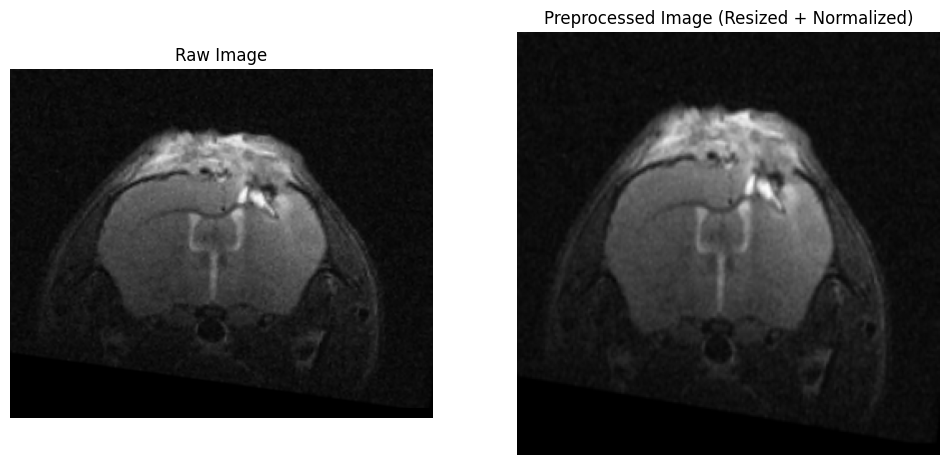

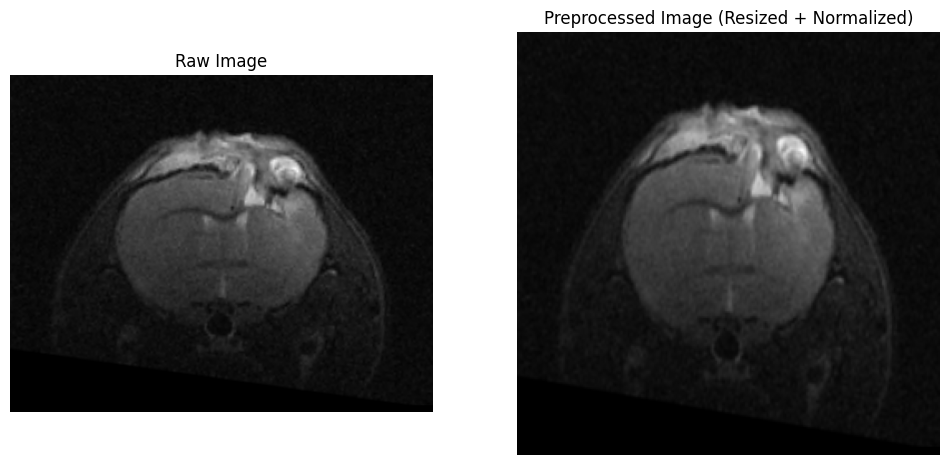

In [6]:
def show_raw_and_processed(path: Path):
    # load raw image with PIL
    raw_img = Image.open(path).convert('RGB')

    # run preprocessing (this returns a torch.Tensor C,H,W)
    tensor = preprocess_image(path)

    # convert back to HWC numpy for display
    processed = tensor.permute(1, 2, 0).cpu().numpy()

    # processed is in [0,1] float32; clip to [0,1] to be safe
    processed = np.clip(processed, 0.0, 1.0)

    # display side-by-side
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(raw_img)
    plt.title('Raw Image')
    plt.axis('off')

    plt.subplot(1,2,2)
    # matplotlib expects float image in HxW[xC] with channels last
    plt.imshow(processed)
    plt.title('Preprocessed Image (Resized + Normalized)')
    plt.axis('off')

    plt.show()

    # return tensor for inspection
    return tensor

if files:
    tensors = []
    for p in sample_paths:
        try:
            t = show_raw_and_processed(p)
            tensors.append((p, t))
        except Exception as e:
            print(f"Error processing {p}: {e}")

In [7]:
# final cell: print tensor diagnostics for processed images
for p, tensor in tensors:
    t_min = float(tensor.min().item())
    t_max = float(tensor.max().item())
    print(f"{p} -> shape={tuple(tensor.shape)}, dtype={tensor.dtype}, min={t_min:.6f}, max={t_max:.6f}")

/Users/jonatanbuga/Desktop/MRI-Project/data/raw/1 Week/Combined/Combined 1/Slice 19.png -> shape=(3, 256, 256), dtype=torch.float32, min=0.000000, max=1.000000
/Users/jonatanbuga/Desktop/MRI-Project/data/raw/1 Week/Combined/Combined 1/Slice 20.png -> shape=(3, 256, 256), dtype=torch.float32, min=0.000000, max=1.000000
